# LINEAR REGRESSION

In [1]:
# Local environment setup
from pathlib import Path

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import gradio as gr

In [3]:
from pathlib import Path

DATASET_PATH = Path("household_power_consumption.csv")
if not DATASET_PATH.exists() and (Path("FRANCE_DATASET") / "household_power_consumption.csv").exists():
    DATASET_PATH = Path("FRANCE_DATASET") / "household_power_consumption.csv"

file_path = DATASET_PATH

df = pd.read_csv(
    file_path,
    sep=';',
    header=None
)

print("Original dataset shape:", df.shape)

df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_19524\1389799809.py:9: DtypeWarning: Columns (0: 2, 1: 3, 2: 4, 3: 5, 4: 6, 5: 7, 6: 8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Original dataset shape: (2075260, 9)


,0,1,2,3,4,5,6,7,8
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [4]:
df.columns = [
    'Date',
    'Time',
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

print("Columns:")
print(df.columns.tolist())

df.head()

Columns:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [5]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (2075260, 9)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2075260 entries, 0 to 2075259
Data columns (total 9 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   Date                   str   
 1   Time                   str   
 2   Global_active_power    object
 3   Global_reactive_power  object
 4   Voltage                object
 5   Global_intensity       object
 6   Sub_metering_1         object
 7   Sub_metering_2         object
 8   Sub_metering_3         object
dtypes: object(7), str(2)
memory usage: 176.0+ MB

Missing values:
Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64


In [6]:
df = df.replace('?', np.nan)

print("Missing values after replacing '?':")
print(df.isnull().sum())

Missing values after replacing '?':
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [7]:
numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


In [8]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

print(df[['Date', 'Time', 'Datetime']].head())

         Date      Time            Datetime
0        Date      Time                 NaT
1  16/12/2006  17:24:00 2006-12-16 17:24:00
2  16/12/2006  17:25:00 2006-12-16 17:25:00
3  16/12/2006  17:26:00 2006-12-16 17:26:00
4  16/12/2006  17:27:00 2006-12-16 17:27:00


In [9]:
df = df.dropna(
    subset=[
        'Datetime',
        'Global_active_power'
    ]
)

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (2049280, 10)


In [10]:
df = df.sort_values('Datetime')

df = df.reset_index(drop=True)

print(df[['Datetime', 'Global_active_power']].head())

             Datetime  Global_active_power
0 2006-12-16 17:24:00                4.216
1 2006-12-16 17:25:00                5.360
2 2006-12-16 17:26:00                5.374
3 2006-12-16 17:27:00                5.388
4 2006-12-16 17:28:00                3.666


In [11]:
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['Hour'] = df['Datetime'].dt.hour
df['Minute'] = df['Datetime'].dt.minute
df['DayOfWeek'] = df['Datetime'].dt.dayofweek

df['IsWeekend'] = (
    df['DayOfWeek'] >= 5
).astype(int)

print(
    df[
        [
            'Datetime',
            'Year',
            'Month',
            'Day',
            'Hour',
            'Minute',
            'DayOfWeek',
            'IsWeekend'
        ]
    ].head()
)

             Datetime  Year  Month  Day  Hour  Minute  DayOfWeek  IsWeekend
0 2006-12-16 17:24:00  2006     12   16    17      24          5          1
1 2006-12-16 17:25:00  2006     12   16    17      25          5          1
2 2006-12-16 17:26:00  2006     12   16    17      26          5          1
3 2006-12-16 17:27:00  2006     12   16    17      27          5          1
4 2006-12-16 17:28:00  2006     12   16    17      28          5          1


In [12]:
df['Power_Lag_1'] = df['Global_active_power'].shift(1)

df['Power_Lag_5'] = df['Global_active_power'].shift(5)

df['Power_Lag_15'] = df['Global_active_power'].shift(15)

df['Power_Lag_60'] = df['Global_active_power'].shift(60)

df['Power_Lag_1440'] = df['Global_active_power'].shift(1440)

In [13]:
df = df.dropna()

df = df.reset_index(drop=True)

print("Dataset shape after lag features:", df.shape)

Dataset shape after lag features: (2047840, 22)


In [14]:
FEATURE_COLUMNS = [
    'Power_Lag_1',
    'Power_Lag_5',
    'Power_Lag_15',
    'Power_Lag_60',
    'Power_Lag_1440',
    'Year',
    'Month',
    'Day',
    'Hour',
    'Minute',
    'DayOfWeek',
    'IsWeekend'
]

TARGET_COLUMN = 'Global_active_power'

X = df[FEATURE_COLUMNS]

y = df[TARGET_COLUMN]

print("Features:")
print(FEATURE_COLUMNS)

print("\nTarget:")
print(TARGET_COLUMN)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['Power_Lag_1', 'Power_Lag_5', 'Power_Lag_15', 'Power_Lag_60', 'Power_Lag_1440', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'DayOfWeek', 'IsWeekend']

Target:
Global_active_power

X shape: (2047840, 12)
y shape: (2047840,)


In [15]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1638272
Testing samples: 409568


In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [17]:
y_pred = model.predict(X_test)

print("First 10 actual values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 predicted values:")
print(y_pred[:10])

First 10 actual values:
[1.652 1.656 1.67  1.664 1.674 1.658 1.666 1.648 1.674 1.672]

First 10 predicted values:
[1.6287104  1.64008181 1.64349906 1.65615987 1.65066442 1.66012939
 1.64538693 1.65273355 1.63652129 1.66045932]


In [18]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n===== Linear Regression Results =====")

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


===== Linear Regression Results =====
MAE  : 0.0850
MSE  : 0.0486
RMSE : 0.2204
R²   : 0.9395


In [19]:
linear_regression_results = {
    'Model': 'Linear Regression',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2
}

print(linear_regression_results)

{'Model': 'Linear Regression', 'MAE': 0.08501767276247003, 'MSE': 0.048574058305507456, 'RMSE': np.float64(0.220395232038961), 'R2': 0.9394988467966248}


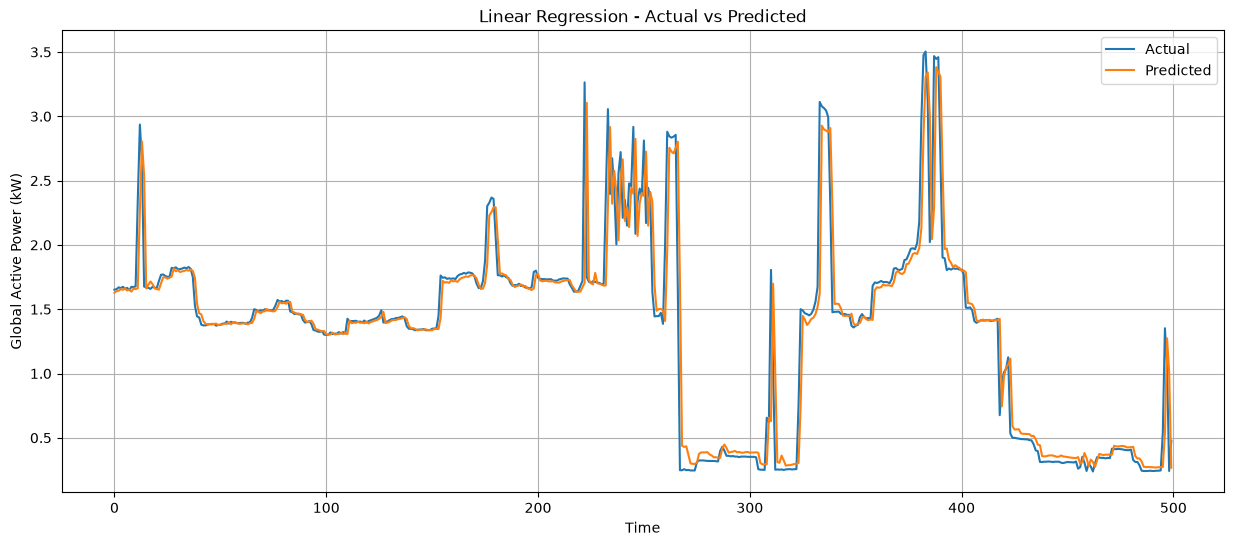

In [20]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.iloc[:500].values,
    label='Actual'
)

plt.plot(
    y_pred[:500],
    label='Predicted'
)

plt.title('Linear Regression - Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')

plt.legend()
plt.grid(True)

plt.show()

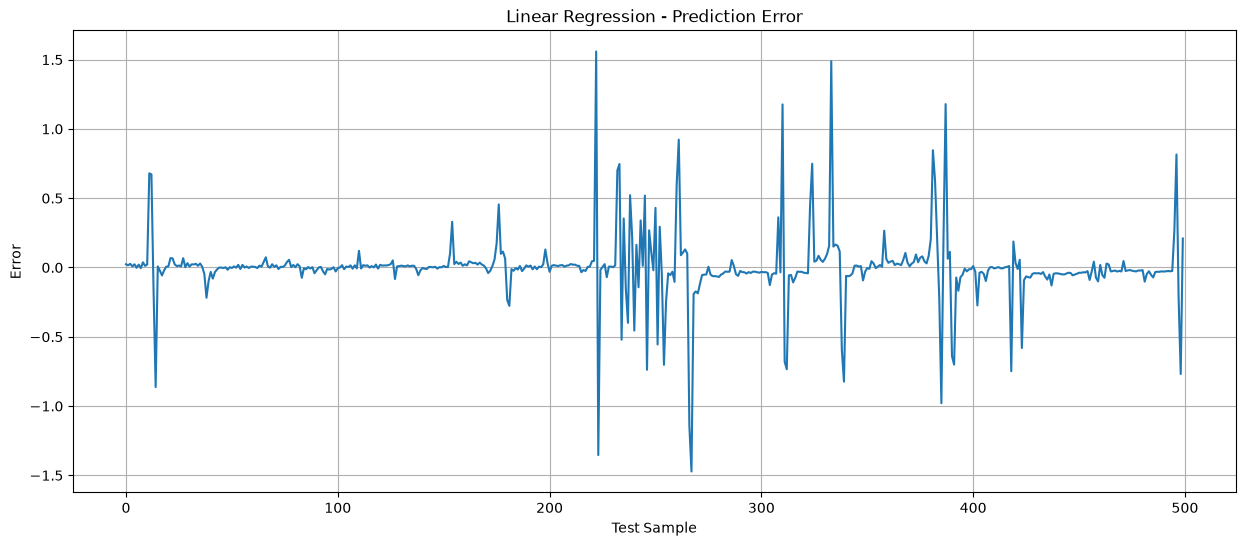

In [21]:
errors = y_test.values - y_pred

plt.figure(figsize=(15, 6))

plt.plot(errors[:500])

plt.title('Linear Regression - Prediction Error')
plt.xlabel('Test Sample')
plt.ylabel('Error')

plt.grid(True)

plt.show()

In [22]:
def predict_power(
    power_lag_1,
    power_lag_5,
    power_lag_15,
    power_lag_60,
    power_lag_1440,
    year,
    month,
    day,
    hour,
    minute,
    day_of_week
):

    is_weekend = 1 if day_of_week >= 5 else 0

    input_data = pd.DataFrame({
        'Power_Lag_1': [power_lag_1],
        'Power_Lag_5': [power_lag_5],
        'Power_Lag_15': [power_lag_15],
        'Power_Lag_60': [power_lag_60],
        'Power_Lag_1440': [power_lag_1440],
        'Year': [year],
        'Month': [month],
        'Day': [day],
        'Hour': [hour],
        'Minute': [minute],
        'DayOfWeek': [day_of_week],
        'IsWeekend': [is_weekend]
    })

    prediction = model.predict(input_data)[0]

    return f"{prediction:.4f} kW"

In [23]:
# ==============================================================================
# Pure Dark Theme & Glassmorphism Gradio UI: Smart Grid Power Forecasting
# ==============================================================================
import gradio as gr

# Preserve original prediction function and add validation error handling
_orig_predict_predict_power = predict_power

def predict_power(power_lag_1, power_lag_5, power_lag_15, power_lag_60, power_lag_1440, year, month, day, hour, minute, day_of_week):
    try:
        vals = [power_lag_1, power_lag_5, power_lag_15, power_lag_60, power_lag_1440, year, month, day, hour, minute, day_of_week]
        if any(v is None for v in vals):
            return "⚠️ Please enter all required numerical values."
        res = _orig_predict_predict_power(power_lag_1, power_lag_5, power_lag_15, power_lag_60, power_lag_1440, year, month, day, hour, minute, day_of_week)
        if isinstance(res, str) and res.startswith("Error:"):
            return "⚠️ Error calculating prediction. Please verify input values."
        return res
    except Exception:
        return "⚠️ Please enter valid numerical inputs."

CUSTOM_CSS = """
/* ==============================================================================
   PURE DARK THEME & GLASSMORPHISM CYBER-GRID CSS (PBL AI DASHBOARD)
   ============================================================================== */

:root, html, body, .gradio-container {
    color-scheme: dark !important;
    background-color: #0b0f19 !important;
    color: #f1f5f9 !important;
    --body-background-fill: #0b0f19 !important;
    --background-fill-primary: #0f172a !important;
    --background-fill-secondary: #1e293b !important;
    --border-color-primary: rgba(255, 255, 255, 0.1) !important;
    --border-color-secondary: rgba(255, 255, 255, 0.08) !important;
    --block-background-fill: #0f172a !important;
    --block-border-color: rgba(255, 255, 255, 0.1) !important;
    --block-label-text-color: #94a3b8 !important;
    --block-title-text-color: #f8fafc !important;
    --input-background-fill: #0f172a !important;
    --input-border-color: rgba(255, 255, 255, 0.15) !important;
    --input-placeholder-color: #64748b !important;
    --body-text-color: #f1f5f9 !important;
    --body-text-color-subdued: #94a3b8 !important;
    --slider-color: #38bdf8 !important;
}

body, html {
    background-color: #0b0f19 !important;
    color: #f1f5f9 !important;
}

.gradio-container {
    max-width: 1040px !important;
    margin: 0 auto !important;
    background: radial-gradient(circle at top left, #0f172a 0%, #030712 100%) !important;
    color: #f1f5f9 !important;
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, "Helvetica Neue", sans-serif !important;
    min-height: 100vh !important;
}

@keyframes fadeInScale {
    0% { opacity: 0; transform: translateY(10px) scale(0.99); }
    100% { opacity: 1; transform: translateY(0) scale(1); }
}

/* Glassmorphism Header */
.sg-header-glass {
    background: rgba(15, 23, 42, 0.75) !important;
    backdrop-filter: blur(20px) !important;
    -webkit-backdrop-filter: blur(20px) !important;
    border: 1px solid rgba(255, 255, 255, 0.08) !important;
    border-top: 1px solid rgba(56, 189, 248, 0.4) !important;
    border-radius: 22px !important;
    padding: 28px 32px 24px !important;
    margin-bottom: 22px !important;
    text-align: center !important;
    box-shadow: 0 16px 36px -10px rgba(0, 0, 0, 0.6) !important;
    animation: fadeInScale 0.6s cubic-bezier(0.16, 1, 0.3, 1) !important;
    position: relative !important;
    overflow: hidden !important;
    transition: all 0.3s ease !important;
}

.sg-header-glass:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 20px 40px -10px rgba(0, 0, 0, 0.75), 0 0 25px rgba(56, 189, 248, 0.15) !important;
}

.sg-header-glass::before {
    content: '' !important;
    position: absolute !important;
    top: 0 !important;
    left: 20% !important;
    right: 20% !important;
    height: 1px !important;
    background: linear-gradient(90deg, transparent, #38bdf8, #818cf8, transparent) !important;
}

.sg-badge-glass {
    display: inline-flex !important;
    align-items: center !important;
    gap: 8px !important;
    background: rgba(30, 41, 59, 0.8) !important;
    border: 1px solid rgba(56, 189, 248, 0.3) !important;
    color: #38bdf8 !important;
    font-size: 11px !important;
    font-weight: 700 !important;
    text-transform: uppercase !important;
    letter-spacing: 0.1em !important;
    padding: 5px 16px !important;
    border-radius: 9999px !important;
    margin-bottom: 12px !important;
    box-shadow: 0 0 15px rgba(56, 189, 248, 0.15) !important;
}

.sg-title-glass {
    font-size: 28px !important;
    font-weight: 800 !important;
    color: #ffffff !important;
    letter-spacing: -0.02em !important;
    margin: 0 0 4px 0 !important;
    text-shadow: 0 2px 10px rgba(0, 0, 0, 0.5) !important;
}

.sg-title-sub-glass {
    font-size: 16px !important;
    font-weight: 600 !important;
    color: #38bdf8 !important;
    margin: 0 0 10px 0 !important;
    letter-spacing: -0.01em !important;
}

.sg-model-tag-glass {
    display: inline-block !important;
    background: rgba(14, 165, 233, 0.12) !important;
    color: #7dd3fc !important;
    font-size: 13px !important;
    font-weight: 700 !important;
    padding: 5px 16px !important;
    border-radius: 10px !important;
    border: 1px solid rgba(56, 189, 248, 0.25) !important;
    margin-bottom: 8px !important;
}

.sg-subtitle-glass {
    font-size: 13px !important;
    color: #94a3b8 !important;
    margin: 0 !important;
}

/* Glass Cards */
.sg-card-glass {
    background: rgba(15, 23, 42, 0.65) !important;
    backdrop-filter: blur(16px) !important;
    -webkit-backdrop-filter: blur(16px) !important;
    border: 1px solid rgba(255, 255, 255, 0.08) !important;
    border-radius: 18px !important;
    padding: 18px 20px !important;
    margin-bottom: 16px !important;
    box-shadow: 0 10px 25px -5px rgba(0, 0, 0, 0.4) !important;
    transition: all 0.3s cubic-bezier(0.16, 1, 0.3, 1) !important;
    animation: fadeInScale 0.7s cubic-bezier(0.16, 1, 0.3, 1) !important;
}

.sg-card-glass:hover {
    transform: translateY(-2px) !important;
    border-color: rgba(56, 189, 248, 0.3) !important;
    box-shadow: 0 14px 32px -4px rgba(0, 0, 0, 0.6), 0 0 20px rgba(56, 189, 248, 0.1) !important;
}

.sg-card-header-glass {
    font-size: 14px !important;
    font-weight: 700 !important;
    color: #f8fafc !important;
    margin-bottom: 12px !important;
    display: flex !important;
    align-items: center !important;
    gap: 8px !important;
    text-transform: uppercase !important;
    letter-spacing: 0.05em !important;
}

/* Futuristic Glowing Button */
.sg-btn-glow {
    background: linear-gradient(135deg, #0284c7 0%, #2563eb 50%, #4f46e5 100%) !important;
    color: #ffffff !important;
    font-weight: 700 !important;
    font-size: 15px !important;
    border: 1px solid rgba(255, 255, 255, 0.2) !important;
    border-radius: 14px !important;
    padding: 13px 26px !important;
    box-shadow: 0 0 20px rgba(14, 165, 233, 0.35), 0 4px 12px rgba(0, 0, 0, 0.5) !important;
    cursor: pointer !important;
    transition: all 0.25s ease !important;
    width: 100% !important;
}

.sg-btn-glow:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 0 30px rgba(14, 165, 233, 0.6), 0 8px 24px rgba(0, 0, 0, 0.6) !important;
    filter: brightness(1.1) !important;
}

.sg-btn-glow:active {
    transform: translateY(0) !important;
}

/* Dark Component Overrides */
.gradio-container input,
.gradio-container textarea,
.gradio-container .block,
.gradio-container .form,
.gradio-container fieldset,
.gradio-container .input-container {
    background-color: #0f172a !important;
    color: #f8fafc !important;
    border-color: rgba(255, 255, 255, 0.12) !important;
    border-radius: 12px !important;
}

.gradio-container input:focus,
.gradio-container textarea:focus {
    border-color: #38bdf8 !important;
    box-shadow: 0 0 12px rgba(56, 189, 248, 0.3) !important;
}

.gradio-container label,
.gradio-container label span {
    color: #94a3b8 !important;
    font-weight: 600 !important;
}

/* Info Grid & Meta Rows */
.sg-info-grid-glass {
    display: grid !important;
    grid-template-columns: repeat(auto-fit, minmax(260px, 1fr)) !important;
    gap: 16px !important;
    margin-top: 18px !important;
}

.sg-meta-row-glass {
    display: flex !important;
    justify-content: space-between !important;
    align-items: center !important;
    font-size: 13px !important;
    padding: 6px 0 !important;
    border-bottom: 1px dashed rgba(255, 255, 255, 0.08) !important;
}

.sg-meta-row-glass:last-child {
    border-bottom: none !important;
}

.sg-meta-row-glass span {
    color: #94a3b8 !important;
}

.sg-meta-row-glass strong {
    color: #38bdf8 !important;
    font-weight: 600 !important;
}

.sg-unit-box-glass {
    background: rgba(16, 185, 129, 0.12) !important;
    border: 1px solid rgba(16, 185, 129, 0.35) !important;
    border-radius: 12px !important;
    padding: 12px 14px !important;
    margin: 10px 0 !important;
    text-align: center !important;
    box-shadow: 0 0 20px rgba(16, 185, 129, 0.12) !important;
}

.sg-unit-val-glass {
    font-size: 18px !important;
    font-weight: 800 !important;
    color: #34d399 !important;
    letter-spacing: -0.01em !important;
}

.sg-unit-desc-glass {
    font-size: 11px !important;
    color: #a7f3d0 !important;
    margin-top: 3px !important;
}

/* Footer */
.sg-footer-glass {
    text-align: center !important;
    padding: 24px 16px 12px !important;
    margin-top: 28px !important;
    border-top: 1px solid rgba(255, 255, 255, 0.08) !important;
    color: #64748b !important;
    font-size: 12px !important;
    line-height: 1.6 !important;
}

.sg-footer-title-glass {
    font-weight: 700 !important;
    color: #cbd5e1 !important;
    font-size: 13px !important;
    margin-bottom: 4px !important;
}
"""

with gr.Blocks(title="Smart Grid Power Forecasting - Linear Regression") as demo:
    gr.HTML(f"<style>{CUSTOM_CSS}</style>")
    
    # Futuristic Glass Header
    gr.HTML("""
    <div class="sg-header-glass">
        <div class="sg-badge-glass">⚡ SMART GRID TELEMETRY • Machine Learning Baseline</div>
        <div class="sg-title-glass">⚡ Smart Grid Power Forecasting</div>
        <div class="sg-title-sub-glass">Household Electricity Consumption Forecasting</div>
        <div class="sg-model-tag-glass">⚡ Linear Regression Model Engine</div>
        <p class="sg-subtitle-glass">AI-powered predictive forecasting of household electricity consumption</p>
    </div>
    """)
    
    # Input Section: Previous Power Consumption (Lag Features)
    gr.HTML("""
    <div class="sg-card-header-glass">
        <span>🔮</span>
        <strong>Historical Power Lag Features (kW)</strong>
    </div>
    """)
    with gr.Row():
        power_lag_1 = gr.Number(label="Power 1 Minute Ago (kW)", value=1.0)
        power_lag_5 = gr.Number(label="Power 5 Minutes Ago (kW)", value=1.0)
        power_lag_15 = gr.Number(label="Power 15 Minutes Ago (kW)", value=1.0)
    with gr.Row():
        power_lag_60 = gr.Number(label="Power 1 Hour Ago (kW)", value=1.0)
        power_lag_1440 = gr.Number(label="Power 1 Day Ago (kW)", value=1.0)

    # Input Section: Date & Time Features
    gr.HTML("""
    <div class="sg-card-header-glass" style="margin-top: 14px;">
        <span>📅</span>
        <strong>Date &amp; Time Temporal Parameters</strong>
    </div>
    """)
    with gr.Row():
        year = gr.Number(label="Year", value=2007)
        month = gr.Slider(minimum=1, maximum=12, step=1, value=1, label="Month")
        day = gr.Slider(minimum=1, maximum=31, step=1, value=1, label="Day")
    with gr.Row():
        hour = gr.Slider(minimum=0, maximum=23, step=1, value=12, label="Hour")
        minute = gr.Slider(minimum=0, maximum=59, step=1, value=0, label="Minute")
        day_of_week = gr.Slider(minimum=0, maximum=6, step=1, value=0, label="Day of Week (0=Mon, 6=Sun)")

    predict_button = gr.Button(
        "⚡ Predict Power Consumption",
        variant="primary",
        elem_classes=["sg-btn-glow"]
    )

    gr.HTML("""
    <div class="sg-card-header-glass" style="margin-top: 16px;">
        <span>📊</span>
        <strong>Power Telemetry Result</strong>
    </div>
    """)
    prediction_output = gr.Textbox(
        label="Predicted Global Active Power",
        placeholder="Prediction will appear here (e.g. 1.2450 kW)...",
        interactive=False
    )

    # Glass Information Cards Grid
    gr.HTML("""
    <div class="sg-info-grid-glass">
        <div class="sg-card-glass">
            <div class="sg-card-header-glass">⚡ Electricity Power Unit</div>
            <div class="sg-unit-box-glass">
                <div class="sg-unit-val-glass">kW — Kilowatts</div>
                <div class="sg-unit-desc-glass">Global Active Power consumption per minute</div>
            </div>
            <p style="font-size: 12px; color: #94a3b8; margin: 6px 0 0 0; line-height: 1.5;">
                Global Active Power represents household power consumption measured per minute.
            </p>
        </div>
        <div class="sg-card-glass">
            <div class="sg-card-header-glass">🤖 Model Architecture</div>
            <div class="sg-meta-row-glass"><span>Model:</span> <strong>Linear Regression</strong></div>
            <div class="sg-meta-row-glass"><span>Dataset:</span> <strong>France Household Power (UCI)</strong></div>
            <div class="sg-meta-row-glass"><span>Target:</span> <strong>Global Active Power</strong></div>
            <div class="sg-meta-row-glass"><span>Unit:</span> <strong>kW (Kilowatts)</strong></div>
            <div class="sg-meta-row-glass"><span>Forecast Type:</span> <strong>Lag Feature Forecast</strong></div>
        </div>
        <div class="sg-card-glass">
            <div class="sg-card-header-glass">🇫🇷 Dataset Telemetry</div>
            <div class="sg-meta-row-glass"><span>Source:</span> <strong>France Household Electric Power</strong></div>
            <div class="sg-meta-row-glass"><span>Target:</span> <strong>Global Active Power</strong></div>
            <div class="sg-meta-row-glass"><span>Frequency:</span> <strong>1-Minute Intervals</strong></div>
            <div class="sg-meta-row-glass"><span>Region:</span> <strong>Sceaux, France</strong></div>
        </div>
    </div>
    <div class="sg-footer-glass">
        <div class="sg-footer-title-glass">⚡ Smart Grid Power Forecasting</div>
        <div>Machine Learning &amp; Deep Learning Project • Linear Regression | SVR | Random Forest | LSTM | XGBoost</div>
        <div style="margin-top: 4px; color: #64748b;">Developed for Academic PBL Project</div>
    </div>
    """)

    # Connect Prediction Function
    predict_button.click(
        fn=predict_power,
        inputs=[
            power_lag_1,
            power_lag_5,
            power_lag_15,
            power_lag_60,
            power_lag_1440,
            year,
            month,
            day,
            hour,
            minute,
            day_of_week
        ],
        outputs=prediction_output
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
